# Activity 3 Signals as Sums of Waves

**Fourier Series in Data Communication**  
**Student:** Michael Jay C. Constantino  
**Program:** BS Software Engineering Fourth Year  
**Course:** SE 4143 Networking  

This notebook reconstructs a square wave and a triangular wave from odd harmonics. It demonstrates that adding harmonics improves the waveform approximation but also increases the highest frequency that the channel must carry.


## Objectives

1. Represent periodic signals as sums of individual harmonics.
2. Construct composite waveforms using a variable number of terms.
3. Compare the results for $N = 4, 8, 100, 1000,$ and $2000$.
4. Connect harmonic count, waveform accuracy, and transmission bandwidth.

## Signal models

The odd-sine series is

$$
g_N(t)=\sum_{k=1}^{N}\frac{1}{2k-1}\sin\left((2k-1)\omega t\right).
$$

It approaches a square wave with levels $\pm\pi/4$. The odd-cosine series is

$$
y_N(t)=\frac{8}{\pi^2}\sum_{k=1}^{N}\frac{1}{(2k-1)^2}\cos\left((2k-1)\omega t\right).
$$

It approaches a triangular wave with amplitude from $-1$ to $1$. For both series, $\omega=2\pi f_0$.


## Imports and plotting style


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 10,
})

print("NumPy and Matplotlib imported successfully.")

NumPy and Matplotlib imported successfully.


## Sampling parameters

The activity allows either 44.1 kHz or 48 kHz. This notebook uses **48,000 samples per second** over **2 seconds**, giving 96,000 samples. The fundamental frequency is 1 Hz, so two full periods are visible. For $N=2000$, the highest included odd harmonic is $3999f_0=3999$ Hz, safely below the 24 kHz Nyquist frequency.


In [ ]:
SAMPLE_RATE = 48_000
DURATION = 2.0
FUNDAMENTAL_FREQUENCY = 1.0
ANGULAR_FREQUENCY = 2 * np.pi * FUNDAMENTAL_FREQUENCY
REQUIRED_N_VALUES = (4, 8, 100, 1000, 2000)

number_of_samples = int(SAMPLE_RATE * DURATION)
time = np.linspace(0, DURATION, number_of_samples, endpoint=False)

print(f"Sampling rate: {SAMPLE_RATE:,} samples/second")
print(f"Duration: {DURATION:.1f} seconds")
print(f"Samples generated: {len(time):,}")
print(f"Nyquist frequency: {SAMPLE_RATE / 2:,.0f} Hz")

Sampling rate: 48,000 samples/second
Duration: 2.0 seconds
Samples generated: 96,000
Nyquist frequency: 24,000 Hz


## Fourier-series functions

Each function accepts `number_of_terms`, so the same program works for any positive value of $N$. The loop adds the odd harmonics $1, 3, 5, \ldots, 2N-1$.

- The sine coefficient is $1/(2k-1)$.
- The cosine coefficient is $1/(2k-1)^2$, followed by the scale factor $8/\pi^2$.


In [3]:
def validate_number_of_terms(number_of_terms):
    if not isinstance(number_of_terms, int) or number_of_terms < 1:
        raise ValueError("N must be a positive whole number.")


def odd_sine_series(time_values, number_of_terms):
    '''Compute the first N terms of the odd-sine Fourier series.'''
    validate_number_of_terms(number_of_terms)
    signal = np.zeros_like(time_values)

    for k in range(1, number_of_terms + 1):
        harmonic = 2 * k - 1
        signal += np.sin(harmonic * ANGULAR_FREQUENCY * time_values) / harmonic

    return signal


def odd_cosine_series(time_values, number_of_terms):
    '''Compute the first N terms of the odd-cosine Fourier series.'''
    validate_number_of_terms(number_of_terms)
    signal = np.zeros_like(time_values)

    for k in range(1, number_of_terms + 1):
        harmonic = 2 * k - 1
        signal += np.cos(harmonic * ANGULAR_FREQUENCY * time_values) / harmonic**2

    return (8 / np.pi**2) * signal


print("Signal-building functions are ready.")

Signal-building functions are ready.


## Ideal reference waveforms and plotting function


In [ ]:
def ideal_square_wave(time_values):
    return (np.pi / 4) * np.sign(np.sin(ANGULAR_FREQUENCY * time_values))


def ideal_triangle_wave(time_values):
    phase = np.mod(FUNDAMENTAL_FREQUENCY * time_values, 1.0)
    return 1 - 4 * np.minimum(phase, 1 - phase)


def plot_waveform(time_values, signal, number_of_terms, series_name, filename):
    if series_name == "Odd Sine Harmonics":
        ideal = ideal_square_wave(time_values)
        color = "#1D4ED8"
    else:
        ideal = ideal_triangle_wave(time_values)
        color = "#EA580C"

    highest_harmonic = 2 * number_of_terms - 1
    figure, axis = plt.subplots(figsize=(10, 4.25))
    axis.plot(
        time_values,
        ideal,
        color="#94A3B8",
        linewidth=1.2,
        linestyle="--",
        label="Ideal waveform",
    )
    axis.plot(
        time_values,
        signal,
        color=color,
        linewidth=1.35,
        label=f"Composite series, N = {number_of_terms}",
    )
    axis.set_title(f"{series_name} | N = {number_of_terms}")
    axis.set_xlabel("Time (seconds)")
    axis.set_ylabel("Amplitude")
    axis.set_xlim(0, DURATION)
    axis.grid(True, alpha=0.25)
    axis.legend(loc="upper right")
    axis.text(
        0.01,
        0.03,
        f"Highest included harmonic: {highest_harmonic}f0 = {highest_harmonic:.0f} Hz",
        transform=axis.transAxes,
        fontsize=9,
        color="#334155",
    )
    figure.tight_layout()
    return figure


print("Plotting functions are ready.")

Plotting functions are ready.


## Variable number of harmonics

In a notebook, the following parameter cell replaces a console prompt. Change `N` to any positive integer and rerun the dependent cells to experiment. The required runs are executed separately below.


In [5]:
N = 4  # Change this value to experiment with another harmonic count.
validate_number_of_terms(N)
print(f"Selected number of harmonic terms: N = {N}")

Selected number of harmonic terms: N = 4


## Required plots

The next five sections run both reconstruction tasks for the required values of $N$. Each code cell saves two files and displays both completed plots.


## Results for N = 4


N = 4: highest included harmonic = 7f0


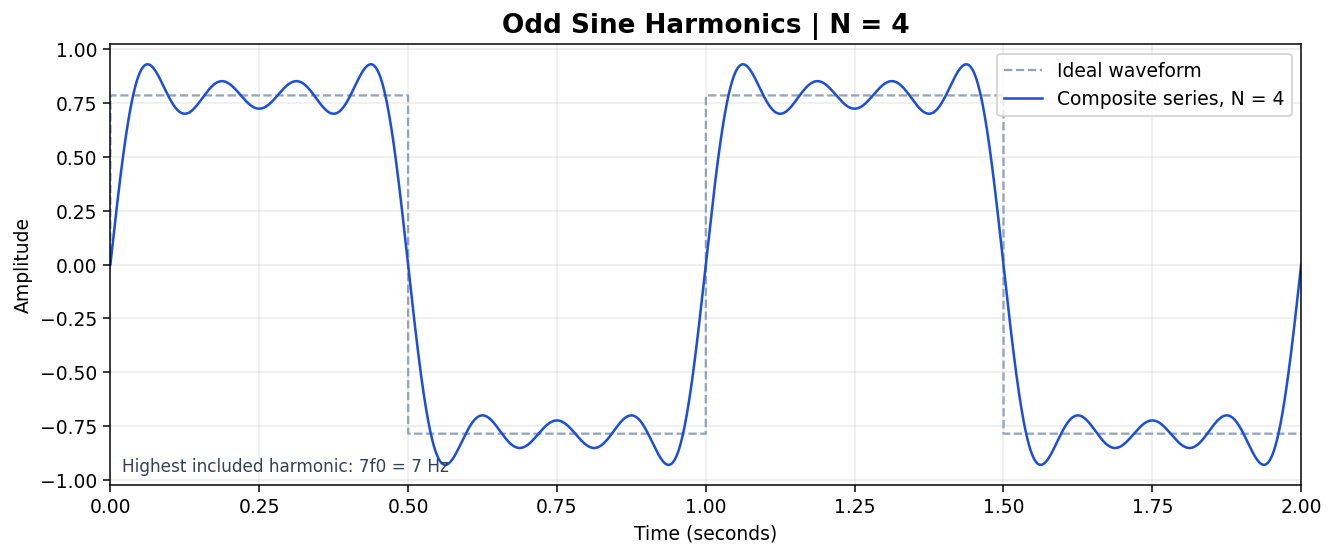

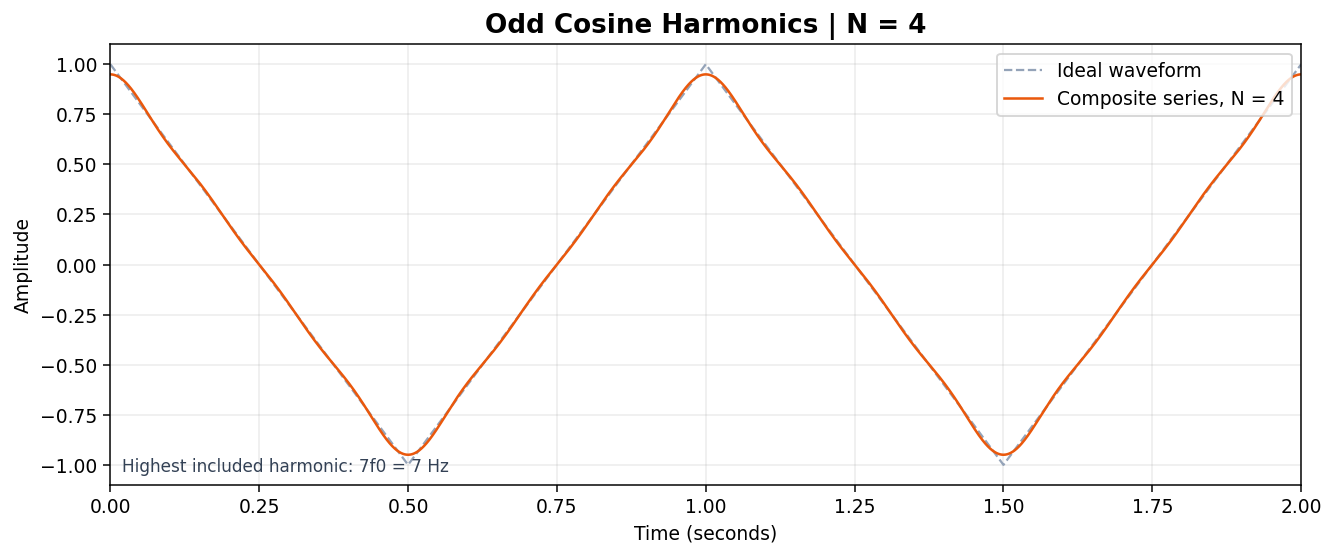

In [6]:
N = 4
sine_signal = odd_sine_series(time, N)
cosine_signal = odd_cosine_series(time, N)

plot_waveform(
    time,
    sine_signal,
    N,
    "Odd Sine Harmonics",
    f"sine_N{N}.png",
)
plot_waveform(
    time,
    cosine_signal,
    N,
    "Odd Cosine Harmonics",
    f"cosine_N{N}.png",
)

print(f"N = {N}: highest included harmonic = {2 * N - 1}f0")

**Observation.** The square-wave estimate contains broad ripples and rounded transitions. The triangular estimate already follows the ideal straight sides closely, with only small errors near the corners.


## Results for N = 8


N = 8: highest included harmonic = 15f0


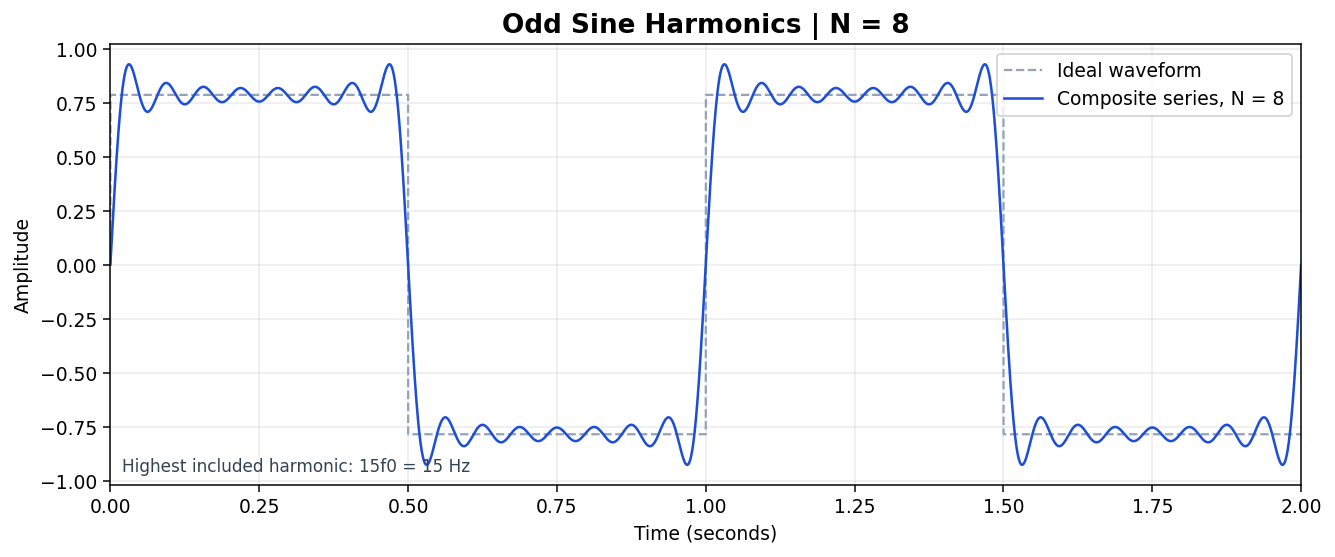

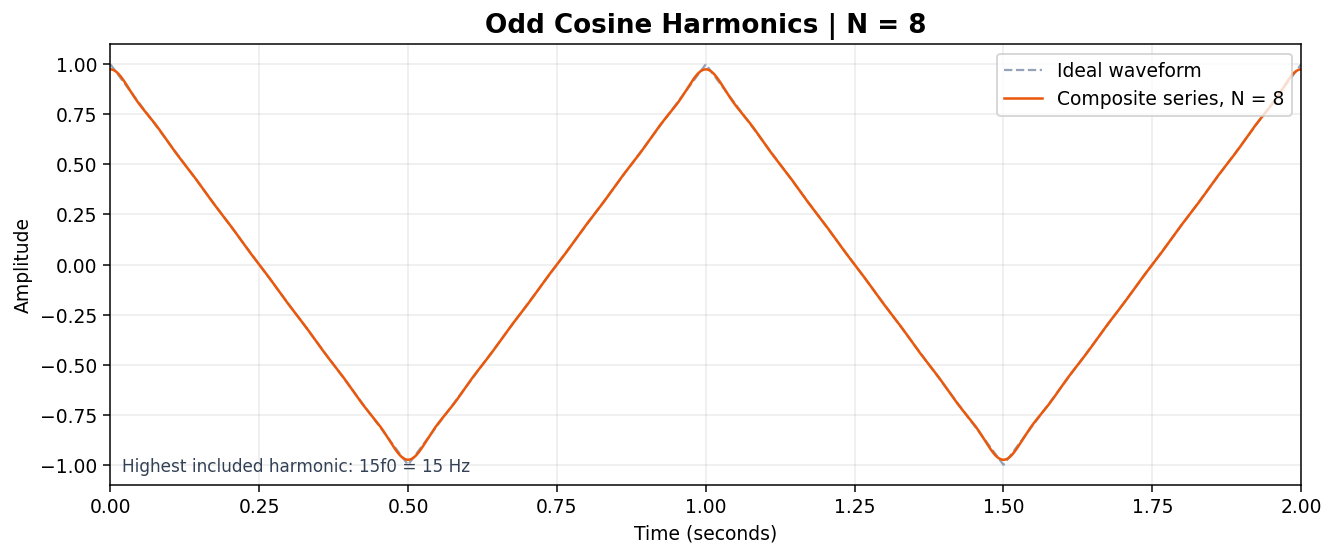

In [7]:
N = 8
sine_signal = odd_sine_series(time, N)
cosine_signal = odd_cosine_series(time, N)

plot_waveform(
    time,
    sine_signal,
    N,
    "Odd Sine Harmonics",
    f"sine_N{N}.png",
)
plot_waveform(
    time,
    cosine_signal,
    N,
    "Odd Cosine Harmonics",
    f"cosine_N{N}.png",
)

print(f"N = {N}: highest included harmonic = {2 * N - 1}f0")

**Observation.** The sine transitions are steeper and the ripples are narrower than at N = 4. The cosine series is already almost indistinguishable from the ideal triangle at normal scale.


## Results for N = 100


N = 100: highest included harmonic = 199f0


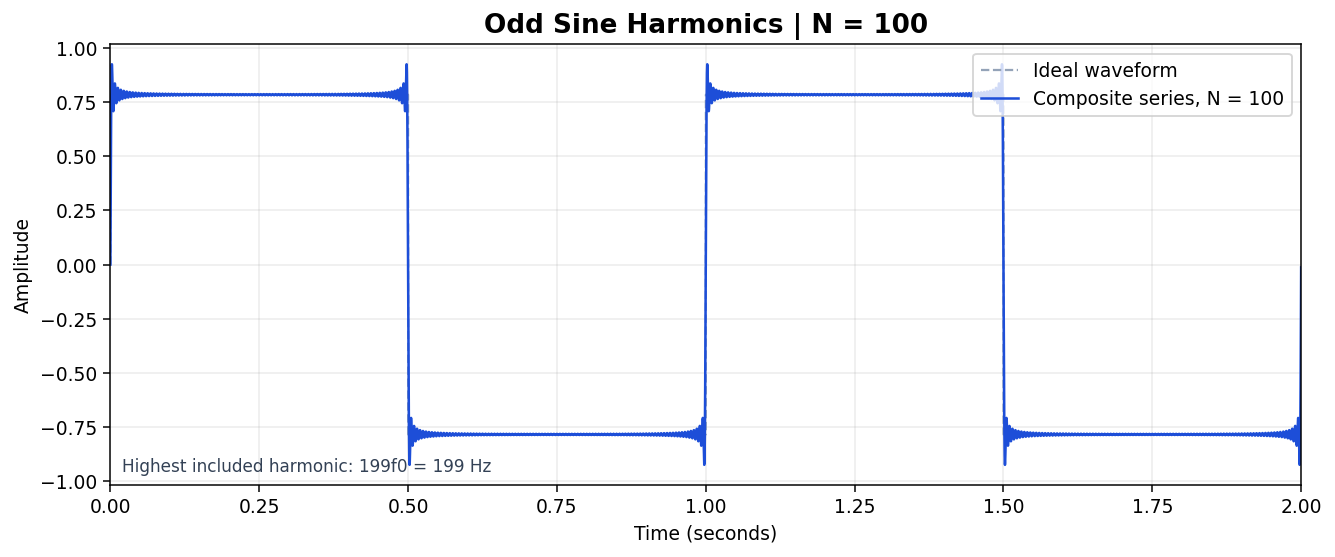

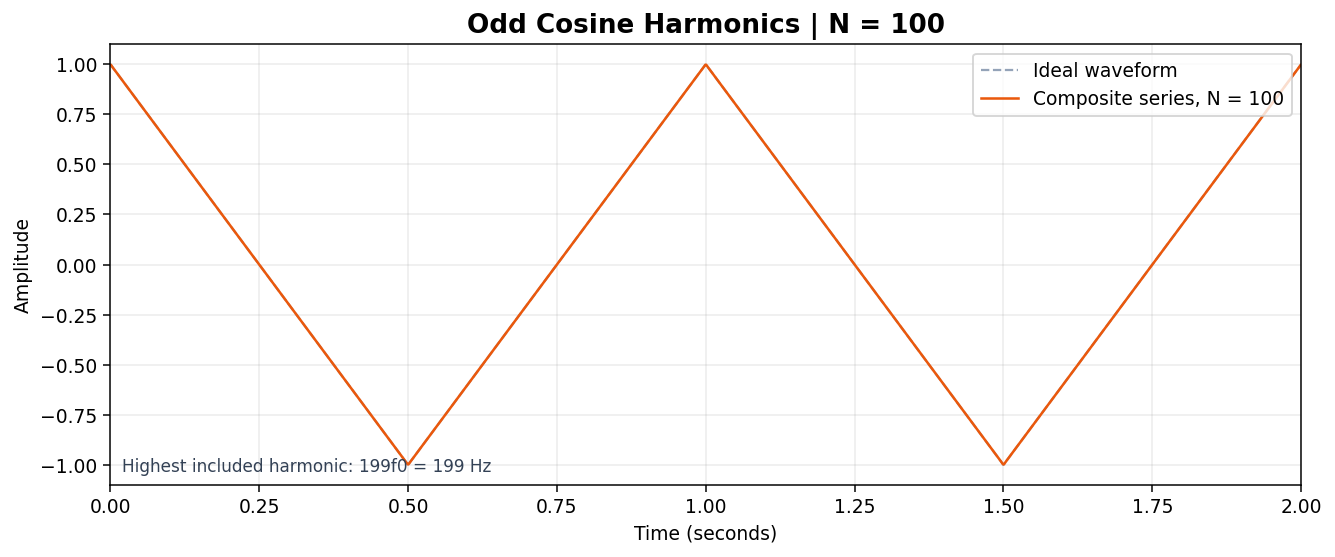

In [8]:
N = 100
sine_signal = odd_sine_series(time, N)
cosine_signal = odd_cosine_series(time, N)

plot_waveform(
    time,
    sine_signal,
    N,
    "Odd Sine Harmonics",
    f"sine_N{N}.png",
)
plot_waveform(
    time,
    cosine_signal,
    N,
    "Odd Cosine Harmonics",
    f"cosine_N{N}.png",
)

print(f"N = {N}: highest included harmonic = {2 * N - 1}f0")

**Observation.** The sine series is nearly flat away from each jump, but concentrated ringing remains near the discontinuities. The cosine curve visually overlaps the ideal triangle.


## Results for N = 1000


N = 1000: highest included harmonic = 1999f0


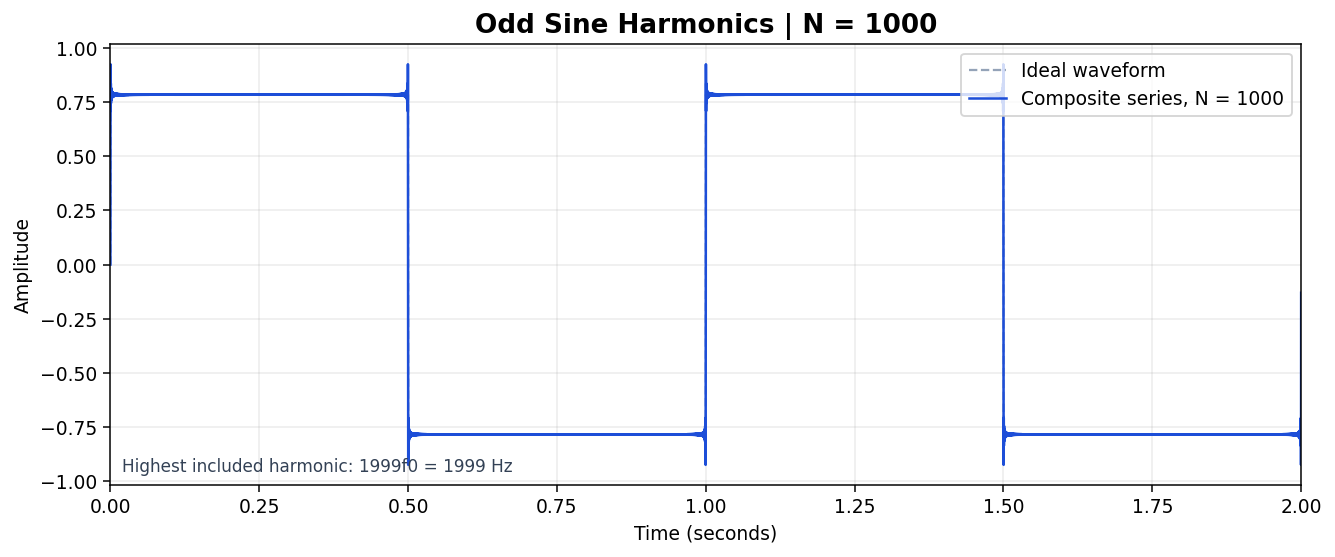

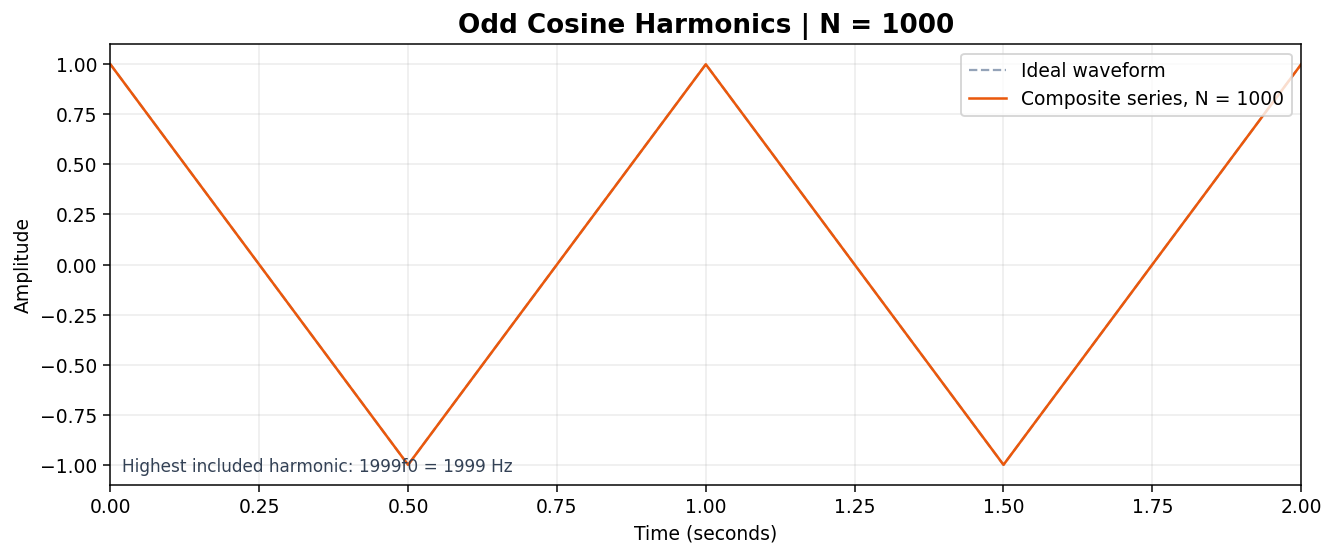

In [9]:
N = 1000
sine_signal = odd_sine_series(time, N)
cosine_signal = odd_cosine_series(time, N)

plot_waveform(
    time,
    sine_signal,
    N,
    "Odd Sine Harmonics",
    f"sine_N{N}.png",
)
plot_waveform(
    time,
    cosine_signal,
    N,
    "Odd Cosine Harmonics",
    f"cosine_N{N}.png",
)

print(f"N = {N}: highest included harmonic = {2 * N - 1}f0")

**Observation.** The square-wave transition region becomes extremely narrow. The overshoot persists near each jump because of the Gibbs phenomenon, while the triangle remains fully converged at this scale.


## Results for N = 2000


N = 2000: highest included harmonic = 3999f0


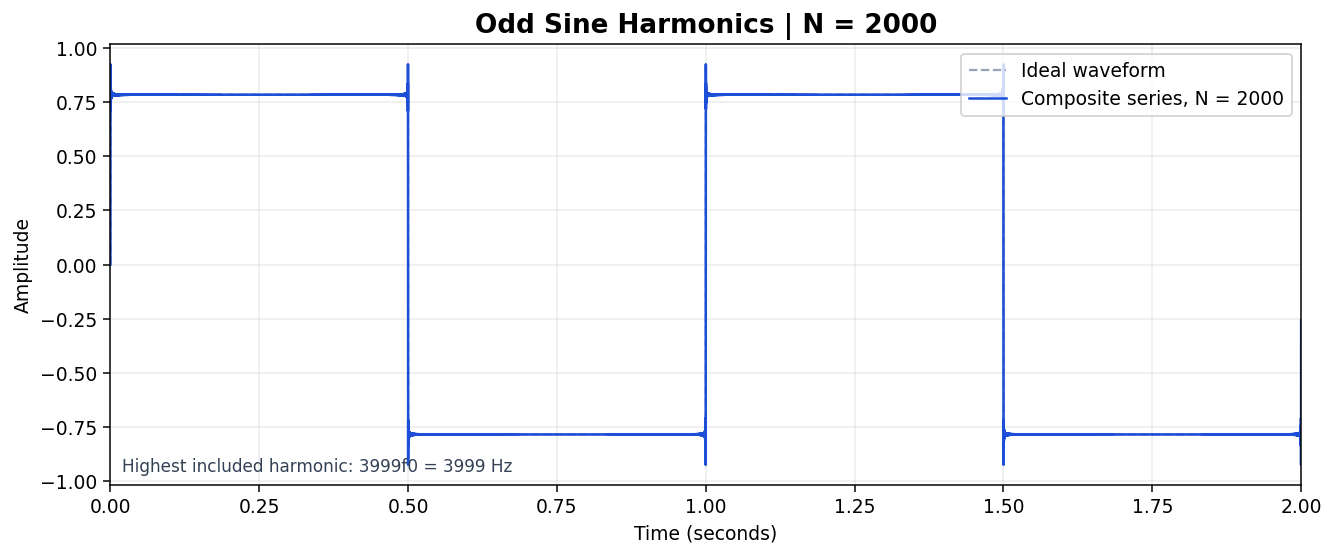

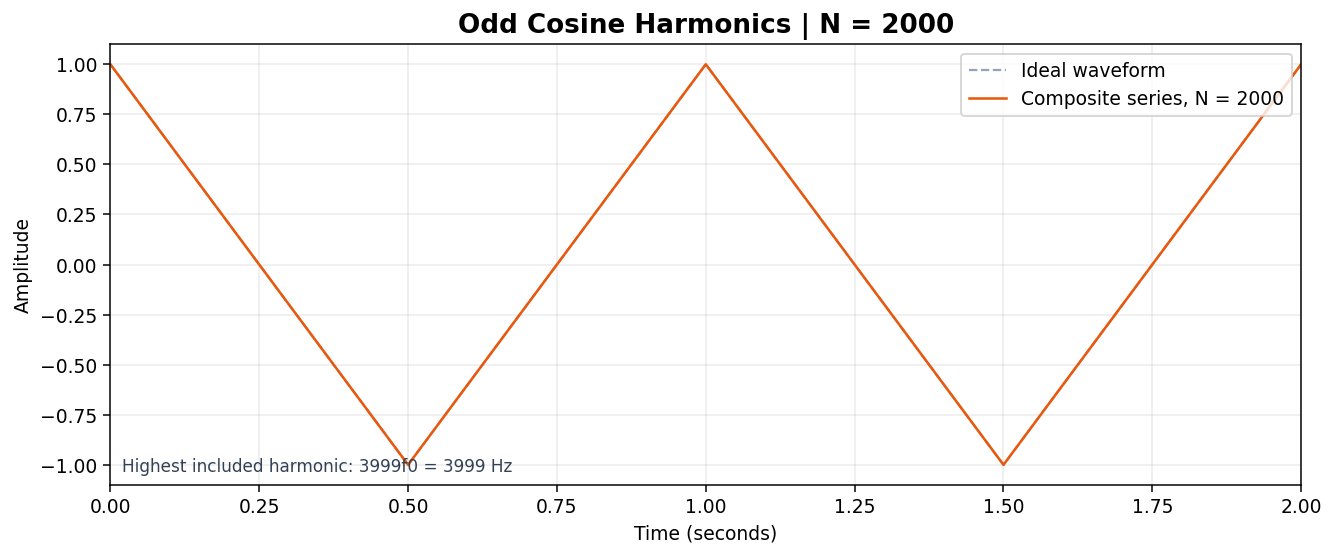

In [10]:
N = 2000
sine_signal = odd_sine_series(time, N)
cosine_signal = odd_cosine_series(time, N)

plot_waveform(
    time,
    sine_signal,
    N,
    "Odd Sine Harmonics",
    f"sine_N{N}.png",
)
plot_waveform(
    time,
    cosine_signal,
    N,
    "Odd Cosine Harmonics",
    f"cosine_N{N}.png",
)

print(f"N = {N}: highest included harmonic = {2 * N - 1}f0")

**Observation.** The curves change very little compared with N = 1000 at normal scale. However, the highest included frequency doubles from 1999 Hz to 3999 Hz, showing diminishing visual improvement for additional bandwidth.


## Harmonic count and bandwidth

For $N$ odd-harmonic terms, the highest included frequency is

$$
f_{\max}=(2N-1)f_0.
$$

Because $f_0=1$ Hz in this activity, the numerical harmonic number and frequency in hertz are equal.


In [11]:
print(f"{'N':>6} {'Highest harmonic':>20} {'Highest frequency':>22}")
print("-" * 52)
for number_of_terms in REQUIRED_N_VALUES:
    highest_harmonic = 2 * number_of_terms - 1
    highest_frequency = highest_harmonic * FUNDAMENTAL_FREQUENCY
    print(
        f"{number_of_terms:>6} "
        f"{str(highest_harmonic) + 'f0':>20} "
        f"{highest_frequency:>18,.0f} Hz"
    )

     N     Highest harmonic      Highest frequency
----------------------------------------------------
     4                  7f0                  7 Hz
     8                 15f0                 15 Hz
   100                199f0                199 Hz
  1000               1999f0              1,999 Hz
  2000               3999f0              3,999 Hz
